In [2]:
# ===== First cell: imports and project setup =====
import sys
import os
from pathlib import Path

# Allow imports from src/ folder (project root)
sys.path.append(str(Path().resolve().parent))

# Standard libraries
import torch
import numpy as np
import matplotlib.pyplot as plt

# Notebook-friendly way to define project root and results folder
PROJECT_ROOT = Path().resolve().parent  # parent of notebooks/
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)  # create folder if it doesn't exist

print("Project root:", PROJECT_ROOT)
print("Results folder:", RESULTS_DIR)

# Optional: display plots inline in notebook
%matplotlib inline

Project root: /Users/bardia/Desktop/pinn-heat-equation
Results folder: /Users/bardia/Desktop/pinn-heat-equation/results


In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# Fix module path mismatch
import src.train as model
sys.modules['model'] = model

from src.train import PINN

# Ensure results folder exists
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

MODEL_PATH = "../pinn_model.pt"

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Cannot find model at {MODEL_PATH}")

# Load model
model = torch.load(MODEL_PATH, weights_only=False)

model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [8]:
import numpy as np

# Create a grid
x = np.linspace(0, 1, 100)
t = np.linspace(0, 1, 100)

X, T = np.meshgrid(x, t)  # 2D grid

In [9]:
# Flatten the grid and convert to torch tensors
inputs_x = torch.tensor(X.flatten()).float().unsqueeze(1)
inputs_t = torch.tensor(T.flatten()).float().unsqueeze(1)

In [10]:
# Predict u(x,t)
with torch.no_grad():  # Disable gradients for inference
    u_pred = model(inputs_x, inputs_t)

# Reshape back to grid
U_pred = u_pred.numpy().reshape(100, 100)

U_exact = np.exp(-np.pi**2 * T) * np.sin(np.pi * X)

## Plot PINN solution

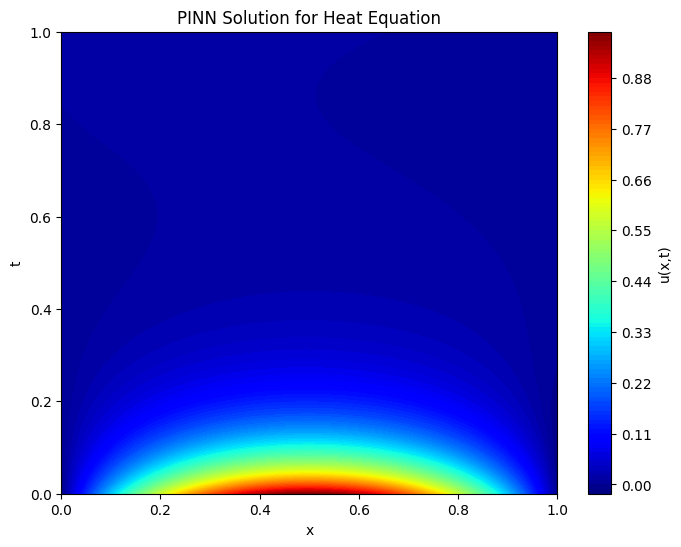

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.contourf(X, T, U_pred, 100, cmap='jet')
plt.colorbar(label='u(x,t)')
plt.xlabel('x')
plt.ylabel('t')
plt.title('PINN Solution for Heat Equation')
plt.show()

In [13]:
# Analytical solution of the heat equation

U_exact = np.exp(-np.pi**2 * T) * np.sin(np.pi * X)

## Plot Analytical solution

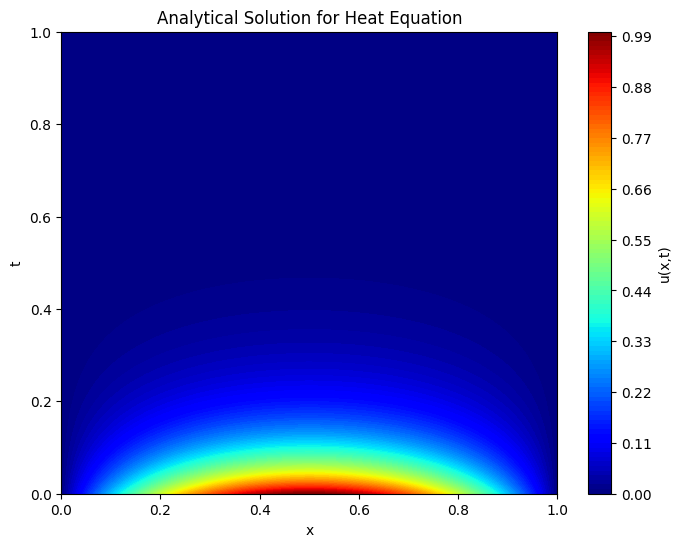

In [14]:
plt.figure(figsize=(8,6))
plt.contourf(X, T, U_exact, 100, cmap='jet')
plt.colorbar(label='u(x,t)')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Analytical Solution for Heat Equation')
plt.show()

## Plot Error

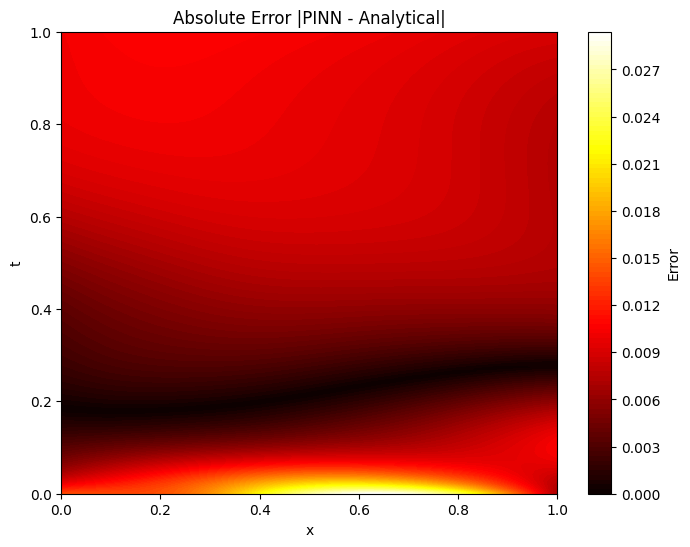

In [15]:
error = np.abs(U_pred - U_exact)

plt.figure(figsize=(8,6))
plt.contourf(X, T, error, 100, cmap='hot')
plt.colorbar(label='Error')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Absolute Error |PINN - Analytical|')
plt.show()